# Matrix Inversion: Gauss-Jordan vs PLU Decomposition

In [13]:
import numpy as np
import scipy.linalg
import time
import matplotlib.pyplot as plt

In [14]:
def generate_invertible_matrix(n, seed= 3301):
    np.random.seed(seed)
    A = np.random.rand(n, n)
    while np.linalg.matrix_rank(A) < n:
        A = np.random.rand(n, n)
    return A


In [15]:
def gauss_jordan_inverse(A):
    n = A.shape[0]
    AI = np.hstack([A.astype(float), np.eye(n)])
    for i in range(n):
        AI[i] = AI[i] / AI[i, i]
        for j in range(n):
            if i != j:
                AI[j] = AI[j] - AI[i] * AI[j, i]
    return AI[:, n:]


In [16]:
def plu_inverse(A):
    P, L, U = scipy.linalg.lu(A)
    inv_A = scipy.linalg.inv(U) @ scipy.linalg.inv(L) @ P.T
    return inv_A


In [17]:
def compare_methods(n):
    A = generate_invertible_matrix(n)

    # Gauss-Jordan
    start_gj = time.time()
    A_inv_gj = gauss_jordan_inverse(A)
    time_gj = time.time() - start_gj
    error_gj = np.linalg.norm(np.eye(n) - A @ A_inv_gj)

    # PLU
    start_plu = time.time()
    A_inv_plu = plu_inverse(A)
    time_plu = time.time() - start_plu
    error_plu = np.linalg.norm(np.eye(n) - A @ A_inv_plu)

    return {
        "Gauss-Jordan": {"time": time_gj, "error": error_gj},
        "PLU": {"time": time_plu, "error": error_plu}
    }


In [18]:
results = compare_methods(n=100)
print(results)

{'Gauss-Jordan': {'time': 0.06133627891540527, 'error': 8.158197026766282e-12}, 'PLU': {'time': 0.0010094642639160156, 'error': 3.934690285798851e-13}}


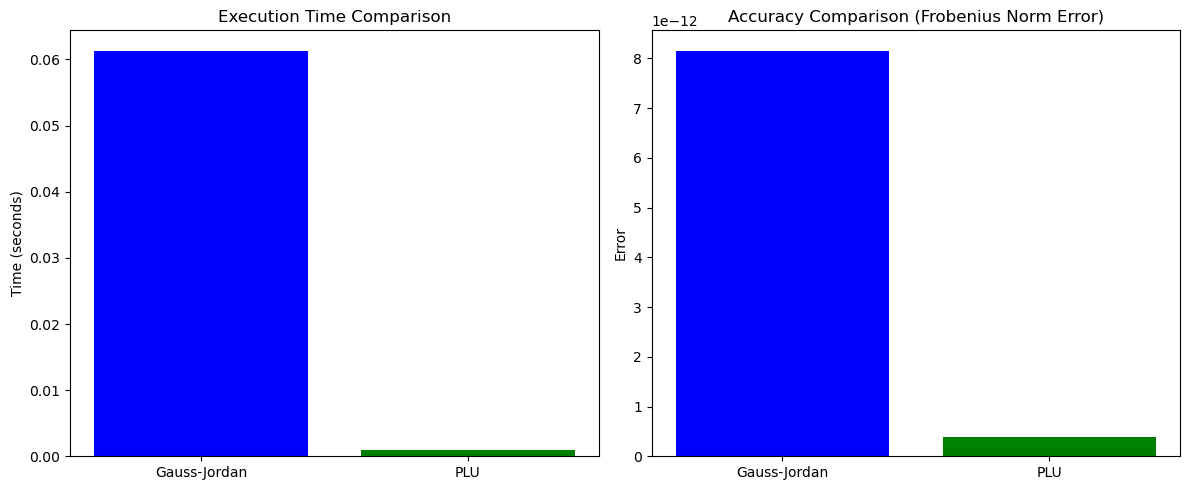

In [19]:
methods = list(results.keys())
times = [results[m]['time'] for m in methods]
errors = [results[m]['error'] for m in methods]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(methods, times, color=['blue', 'green'])
plt.title('Execution Time Comparison')
plt.ylabel('Time (seconds)')

plt.subplot(1, 2, 2)
plt.bar(methods, errors, color=['blue', 'green'])
plt.title('Accuracy Comparison (Frobenius Norm Error)')
plt.ylabel('Error')

plt.tight_layout()
plt.show()

## Exercises

1. Compare the execution times and errors of Gauss-Jordan and PLU methods for n = 100, 200, 300, 400, 500. Which method do you find to be faster for each matrix size? Which method gives the smaller error for each matrix size?
2. Determine the largest matrix size for which your computer can successfully compute the inverse within a reasonable time using each of the following methods:
  
   (a) Gauss-Jordan elimination       (b) numpy.linalg.inv

Start with a moderate matrix size and gradually increase it until the computation becomes very slow or fails due to memory or other limitations.

(i) What is the largest matrix size that your computer can handle for each method?

(ii) How does the execution time change as the matrix size increases?

(iii) Which method is able to handle the largest matrices most efficiently?

In [20]:
def find_largest_size(method, start=100, step=100, max_time=10, max_size=5000):
    largest = 0
    times = []

    for n in range(start, max_size + 1, step):
        try:
            A = generate_invertible_matrix(n)
            start_time = time.time()
            method(A)
            elapsed = time.time() - start_time
            times.append((n, elapsed))

            if elapsed > max_time:
                break

            largest = n
        except:
            break

    return largest, times

gj_largest, gj_times = find_largest_size(gauss_jordan_inverse)
np_largest, np_times = find_largest_size(np.linalg.inv)

print("Largest Gauss-Jordan size:", gj_largest)
print("Largest numpy.linalg.inv size:", np_largest)

print("\nGauss-Jordan:")
for n, t in gj_times:
    print(n, t)

print("\nnumpy.linalg.inv:")
for n, t in np_times:
    print(n, t)

print("\nMost efficient:", "Gauss-Jordan" if gj_largest > np_largest else "numpy.linalg.inv")            

Largest Gauss-Jordan size: 1100
Largest numpy.linalg.inv size: 900

Gauss-Jordan:
100 0.0447232723236084
200 0.15490055084228516
300 0.4372687339782715
400 0.9340481758117676
500 1.5567796230316162
600 2.3870866298675537
700 3.4484221935272217
800 4.819821357727051
900 6.1237921714782715
1000 7.811254501342773
1100 9.999677658081055

numpy.linalg.inv:
100 0.0
200 0.0
300 0.002196073532104492
400 0.014558792114257812
500 0.007661104202270508
600 0.10832500457763672
700 0.14322972297668457
800 0.14885163307189941
900 0.2073516845703125

Most efficient: Gauss-Jordan


In [21]:
sizes = [100, 200, 300, 400, 500, 750, 1000, 1500, 2000, 3000]
limit = 10

print("Gauss-Jordan")
for n in sizes:
    A = generate_invertible_matrix(n)
    start = time.time()
    gauss_jordan_inverse(A)
    elapsed = time.time() - start
    print(n, elapsed)
    if elapsed > limit:
        break

print("\nnumpy.linalg.inv")
for n in sizes:
    A = generate_invertible_matrix(n)
    start = time.time()
    np.linalg.inv(A)
    elapsed = time.time() - start
    print(n, elapsed)
    if elapsed > limit:
        break

Gauss-Jordan
100 0.04320383071899414
200 0.17173075675964355
300 0.4586622714996338
400 0.9416842460632324
500 1.6282119750976562
750 4.166092395782471
1000 7.896187782287598
1500 21.399807691574097

numpy.linalg.inv
100 0.0
200 0.0
300 0.0
400 0.015677928924560547
500 0.04726099967956543
750 0.1261579990386963
1000 0.252591609954834
1500 0.5052971839904785
2000 1.7509396076202393
3000 1.6669461727142334


(i) The largest matrix size for each method is the last value of \(n\) that completes within the 10-second limit. The exact value depends on the output obtained on the computer.

(ii) As the matrix size increases, the execution time increases rapidly. Gauss-Jordan becomes significantly slower for large matrices.

(iii) numpy.linalg.inv() handles larger matrices more efficiently because it is highly optimized and is much faster than the manually implemented Gauss-Jordan method.